In [1]:
from google.colab import files
uploaded = files.upload()


Saving Flat_File_Cleaned_fixed.csv to Flat_File_Cleaned_fixed.csv


In [ ]:
# Cell 1: Kết nối & Query dữ liệu dựa trên Index cung cấp
import pyodbc
import pandas as pd

# 1. Thiết lập thông tin kết nối (Vẫn giữ nguyên)
conn_string = (
    'DRIVER={SQL Server};'
    'SERVER=localhost\\SQLSERVERDEV;'      # TODO: sửa
    'DATABASE=Final_OLAP;'  # TODO: sửa
    'Trusted_Connection=yes;'
)

try:
    conn = pyodbc.connect(conn_string)
    print("Kết nối thành công đến cơ sở dữ liệu.")

    # 2. Xây dựng SQL Query được điều chỉnh
    # Giả định bảng Fact trung tâm là 'Fact_AdEvents' (vì có nhiều thông tin event/user)
    sql_query_refined = """
    SELECT
        -- Từ Dim_Campaigns
        c.campaign_id,
        c.name,
        c.start_date,
        c.end_date,
        c.duration_days,  -- Cột tính toán trong Dim hoặc Fact
        c.total_budget,
        
        -- Từ Dim_Ads
        a.ad_id,
        a.ad_platform,
        a.ad_type,
        a.target_gender,
        a.target_age_group,
        a.target_interests,
        
        -- Từ Dim_Time
        t.timestamp,
        t.day_of_week,
        t.time_of_day,
        t.month,
        t.year,
        t.is_weekend,
        t.day_of_month,
        t.hour,
        t.minute,
        t.second,
        
        -- Từ Dim_Events
        e.event_id,
        e.event_type,      
        
        -- Từ Dim_Users
        u.user_id,
        u.user_gender,
        u.user_age,
        u.age_group,
        u.country,
        u.location,
        u.interests
        
    FROM Fact_Events AS f 
    
    -- Kết nối với các bảng Dimension
    LEFT JOIN Dim_Campaigns AS c ON f.campaign_id  = c.campaign_id
    LEFT JOIN Dim_Ads       AS a ON f.ad_id        = a.ad_id
    LEFT JOIN Dim_Time      AS t ON f.timestamp      = t.timestamp
    LEFT JOIN Dim_Users     AS u ON f.user_id      = u.user_id 
    LEFT JOIN Dim_Events     AS e ON f.event_id     = e.event_id 
    
    
    """

    # 3. Thực thi Query và đọc dữ liệu vào DataFrame
    df_ads = pd.read_sql(sql_query_refined, conn)
    print("\nTruy vấn dữ liệu thành công với cấu trúc cột mới.")
    print(df_ads.head())

except pyodbc.Error as ex:
    sqlstate = ex.args[0]
    print(f"\nLỗi kết nối hoặc truy vấn: {sqlstate}")
    print(ex)

finally:
    # 4. Đóng kết nối
    if 'conn' in locals() and conn:
        conn.close()
        print("\nĐã đóng kết nối.")

In [2]:
import pandas as pd

df = pd.read_csv("Flat_File_Cleaned_fixed.csv")

print("\n=== FIRST 5 ROWS ===")
display(df.head())

print("\n=== COLUMNS (HEADER) ===")
print(df.columns.tolist())




=== FIRST 5 ROWS ===


,user_id,user_gender,user_age,age_group,country,location,interests,event_id,ad_id,timestamp,...,ad_platform,ad_type,target_gender,target_age_group,target_interests,campaigns_name,campaigns_start_date,campaigns_end_date,campaigns_duration_days,campaigns_total_budget
0,a2474,female,24,18-24,united kingdom,new mariomouth,fitness - health,3368,3,7/20/2025 14:18,...,instagram,carousel,All,25-34,technology,Campaign_20_Winter,2/17/2025,5/18/2025,90,98904.66
1,56b94,male,25,25-34,canada,east austin,fitness - photography,96,3,6/24/2025 8:59,...,instagram,carousel,All,25-34,technology,Campaign_20_Winter,2/17/2025,5/18/2025,90,98904.66
2,5b868,male,20,18-24,united states,barrerahaven,fashion - sports - travel,9268,38,5/31/2025 16:05,...,facebook,stories,Male,25-34,finance - technology,Campaign_2_Launch,4/16/2025,7/7/2025,82,79342.41
3,68f1a,male,58,55-65,united kingdom,robinsonberg,finance - lifestyle,5,52,7/22/2025 8:30,...,instagram,stories,Female,35-44,health - lifestyle,Campaign_2_Launch,4/16/2025,7/7/2025,82,79342.41
4,e82c1,male,37,35-44,united states,joneshaven,art,65,1,6/28/2025 10:56,...,facebook,video,Female,35-44,art - technology,Campaign_28_Winter,5/9/2025,6/30/2025,52,32844.79



=== COLUMNS (HEADER) ===
['user_id', 'user_gender', 'user_age', 'age_group', 'country', 'location', 'interests', 'event_id', 'ad_id', 'timestamp', 'day_of_week', 'time_of_day', 'event_type', 'campaign_id', 'ad_platform', 'ad_type', 'target_gender', 'target_age_group', 'target_interests', 'campaigns_name', 'campaigns_start_date', 'campaigns_end_date', 'campaigns_duration_days', 'campaigns_total_budget']


# **Chọn TARGET & loại bỏ cột không nên học**

In [3]:
TARGET = "ad_type"

# Các cột ID / timestamp không dùng làm feature
drop_cols = [
    "user_id",
    "event_id",
    "ad_id",
    "campaigns_name",
    "timestamp",
    "campaigns_start_date",
    "campaigns_end_date"
]

X = df.drop(columns=[TARGET] + drop_cols, errors="ignore")
y = df[TARGET]

print("TARGET:", TARGET)
print("X shape:", X.shape)
print("Classes:", y.unique())


TARGET: ad_type
X shape: (399999, 16)
Classes: ['carousel' 'stories' 'video' 'image']


Mục tiêu: dự đoán loại quảng cáo (carousel/image/stories/video) phù hợp với ngữ cảnh người dùng/campaign.

Lý do chọn ad_type: đây là nhãn đa lớp rõ ràng, liên quan trực tiếp đến tối ưu creative/placement.

# **Chia numeric / categorical**

In [4]:
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)


Categorical columns: ['user_gender', 'age_group', 'country', 'location', 'interests', 'day_of_week', 'time_of_day', 'event_type', 'ad_platform', 'target_gender', 'target_age_group', 'target_interests']
Numerical columns: ['user_age', 'campaign_id', 'campaigns_duration_days', 'campaigns_total_budget']


# **Leakage check**

In [22]:
# Leakage check: mỗi campaign_id có bao nhiêu ad_type khác nhau?
tmp = df.groupby("campaign_id")["ad_type"].nunique().sort_values(ascending=False)

print("Top campaign_id có nhiều ad_type nhất:")
display(tmp.head(10))

only_one = (tmp == 1).mean()
print(f"Tỷ lệ campaign_id chỉ có 1 ad_type: {only_one:.2%}")


Top campaign_id có nhiều ad_type nhất:


,ad_type
campaign_id,
17,4
34,4
46,4
42,4
29,4
33,4
32,4
25,4
23,3


Tỷ lệ campaign_id chỉ có 1 ad_type: 8.33%


Nếu tỷ lệ “campaign chỉ có 1 ad_type” cao → RF đoán dễ

# **Pipeline tiền xử lý + Train/Test split**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Chia dữ liệu thành tập huấn luyện (80%) và kiểm tra (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Pipeline xử lý cho các biến số (numerical features)
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), # Điền giá trị thiếu bằng median
    ("scaler", StandardScaler())  # Chuẩn hóa dữ liệu (cần thiết cho KNN)
])

# Pipeline xử lý cho các biến phân loại (categorical features)
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")), # Điền giá trị thiếu bằng giá trị phổ biến nhất
    ("onehot", OneHotEncoder(handle_unknown="ignore"))  # One-hot encoding, tránh lỗi khi gặp giá trị mới
])

# Kết hợp tiền xử lý cho từng loại biến bằng ColumnTransformer
preprocess = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])


In [20]:
print("Class distribution (y):")
print(y.value_counts(normalize=True))


Class distribution (y):
ad_type
stories     0.320596
image       0.259508
carousel    0.254813
video       0.165083
Name: proportion, dtype: float64


# **KNN**

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# mô hình KNN với k = 5 láng giềng gần nhất
knn_model = Pipeline([
    ("preprocess", preprocess),
    ("clf", KNeighborsClassifier(n_neighbors=5)) # Sử dụng 5 điểm lân cận để dự đoán
])

# Huấn luyện mô hình KNN trên tập train
knn_model.fit(X_train, y_train)

# Dự đoán nhãn cho tập test
knn_pred = knn_model.predict(X_test)

print("=== KNN RESULT ===")
# Accuracy: tỷ lệ dự đoán đúng trên tổng số mẫu
print("Accuracy:", accuracy_score(y_test, knn_pred))


# In ra Precision, Recall, F1-score cho từng lớp
print(classification_report(y_test, knn_pred))

# Ma trận nhầm lẫn: so sánh nhãn dự đoán và nhãn thực tế
print("Confusion matrix:\n", confusion_matrix(y_test, knn_pred))

=== KNN RESULT ===
Accuracy: 0.99045
              precision    recall  f1-score   support

    carousel       0.99      0.99      0.99     20385
       image       0.99      0.99      0.99     20761
     stories       0.99      0.99      0.99     25648
       video       0.99      0.98      0.99     13206

    accuracy                           0.99     80000
   macro avg       0.99      0.99      0.99     80000
weighted avg       0.99      0.99      0.99     80000

Confusion matrix:
 [[20244    48    34    59]
 [  113 20595    44     9]
 [   84    84 25461    19]
 [  102    55   113 12936]]


## **Sơ đồ KNN (Confusion Matrix)**

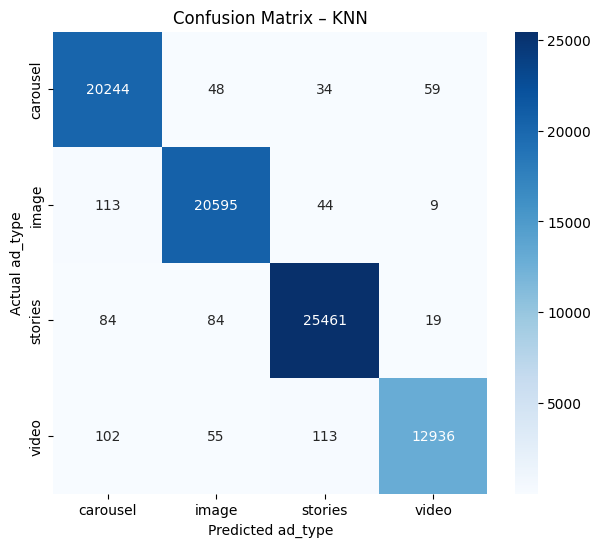

KNN Accuracy: 0.9905


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

labels = sorted(y.unique())
cm_knn = confusion_matrix(y_test, knn_pred, labels=labels)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Confusion Matrix – KNN")
plt.xlabel("Predicted ad_type")
plt.ylabel("Actual ad_type")
plt.show()

print("KNN Accuracy:", round(accuracy_score(y_test, knn_pred), 4))


# **Xuất file KNN**

In [23]:
import pandas as pd

# DataFrame kết quả KNN
knn_results = pd.DataFrame({
    "Actual_ad_type": y_test.values,
    "Predicted_ad_type": knn_pred
})

# Thêm cột đánh dấu đúng/sai
knn_results["Correct"] = knn_results["Actual_ad_type"] == knn_results["Predicted_ad_type"]

# Xuất file Excel
knn_results.to_excel("KNN_Prediction_Results.xlsx", index=False)

print("Đã xuất file KNN_Prediction_Results.xlsx")


Đã xuất file KNN_Prediction_Results.xlsx


# **Nhận định thông qua kết quả KNN**

Độ chính xác đạt 99.05%, cho thấy KNN phân loại rất tốt loại quảng cáo.

Precision, Recall và F1-score của tất cả các lớp đều xấp xỉ 0.99 → mô hình ổn định.

**Phân tích lỗi dự đoán**

- Phần lớn dự đoán nằm đúng trên đường chéo chính của Confusion Matrix.

- Chỉ xuất hiện một số rất ít nhầm lẫn, chủ yếu giữa: carousel và image; stories và video

**Nguyên nhân nhầm lẫn**

KNN dựa trên khoảng cách giữa các điểm dữ liệu, nên khó phân biệt hoàn toàn các lớp có đặc điểm gần nhau.

**Đánh giá**

KNN phù hợp làm mô hình baseline.


# **Random Forest**

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("=== RANDOM FOREST RESULT ===")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, rf_pred))


=== RANDOM FOREST RESULT ===
Accuracy: 1.0
              precision    recall  f1-score   support

    carousel       1.00      1.00      1.00     20385
       image       1.00      1.00      1.00     20761
     stories       1.00      1.00      1.00     25648
       video       1.00      1.00      1.00     13206

    accuracy                           1.00     80000
   macro avg       1.00      1.00      1.00     80000
weighted avg       1.00      1.00      1.00     80000

Confusion matrix:
 [[20385     0     0     0]
 [    0 20761     0     0]
 [    0     0 25648     0]
 [    0     0     0 13206]]


# **Sơ đồ Random Forest (Confusion Matrix)**

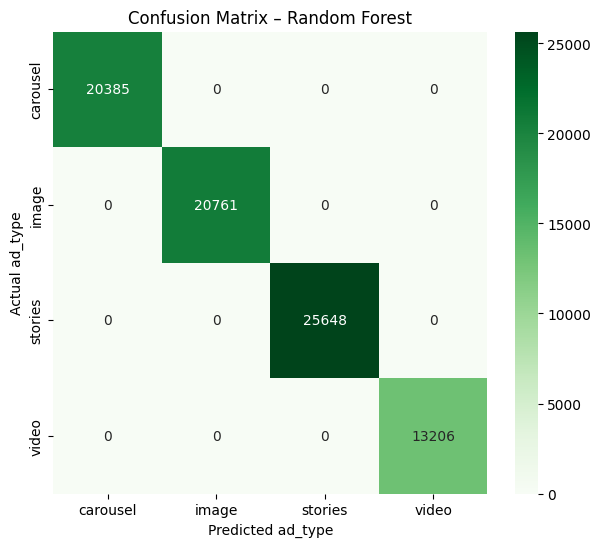

Random Forest Accuracy: 1.0


In [9]:
cm_rf = confusion_matrix(y_test, rf_pred, labels=labels)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Confusion Matrix – Random Forest")
plt.xlabel("Predicted ad_type")
plt.ylabel("Actual ad_type")
plt.show()

print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 4))


# **Nhận định thông qua kết quả Random Forest**

Mô hình Random Forest đạt độ chính xác 100%, tức là tất cả các mẫu trong tập test đều được dự đoán đúng.

Độ chính xác đạt 100% trên tập test.

Precision, Recall, F1-score đều bằng 1.00 cho tất cả các loại quảng cáo.

**Phân tích Confusion Matrix**

- Tất cả giá trị nằm trên đường chéo chính.

- Không có bất kỳ nhầm lẫn nào giữa các lớp.

**Nguyên nhân hiệu suất vượt trội**

- Học được quan hệ phi tuyến giữa các thuộc tính

- Khai thác tốt tương tác giữa người dùng – nền tảng – chiến dịch

- Giảm nhiễu nhờ cơ chế voting của nhiều cây quyết định

**Đánh giá**

- Random Forest là mô hình ổn định và chính xác nhất trong đồ án.

- Phù hợp để sử dụng làm mô hình chính.

# **Xuất file Random Forest**

In [24]:
# DataFrame kết quả Random Forest
rf_results = pd.DataFrame({
    "Actual_ad_type": y_test.values,
    "Predicted_ad_type": rf_pred
})

rf_results["Correct"] = rf_results["Actual_ad_type"] == rf_results["Predicted_ad_type"]

# Xuất file Excel
rf_results.to_excel("RandomForest_Prediction_Results.xlsx", index=False)

print("Đã xuất file RandomForest_Prediction_Results.xlsx")


Đã xuất file RandomForest_Prediction_Results.xlsx


# **Feature importance**

In [10]:
import numpy as np

ohe = rf_model.named_steps["preprocess"] \
    .named_transformers_["cat"] \
    .named_steps["onehot"]

cat_features = ohe.get_feature_names_out(cat_cols)
feature_names = list(num_cols) + list(cat_features)

importances = rf_model.named_steps["clf"].feature_importances_

top = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False).head(20)

display(top)


,feature,importance
1,campaign_id,0.111589
2,campaigns_duration_days,0.108340
3,campaigns_total_budget,0.107319
9364,target_age_group_25-34,0.022461
9361,target_gender_Female,0.022426
9360,target_gender_All,0.021975
9365,target_age_group_35-44,0.021230
9366,target_age_group_All,0.020476
9363,target_age_group_18-24,0.020476
9430,target_interests_photography,0.020457


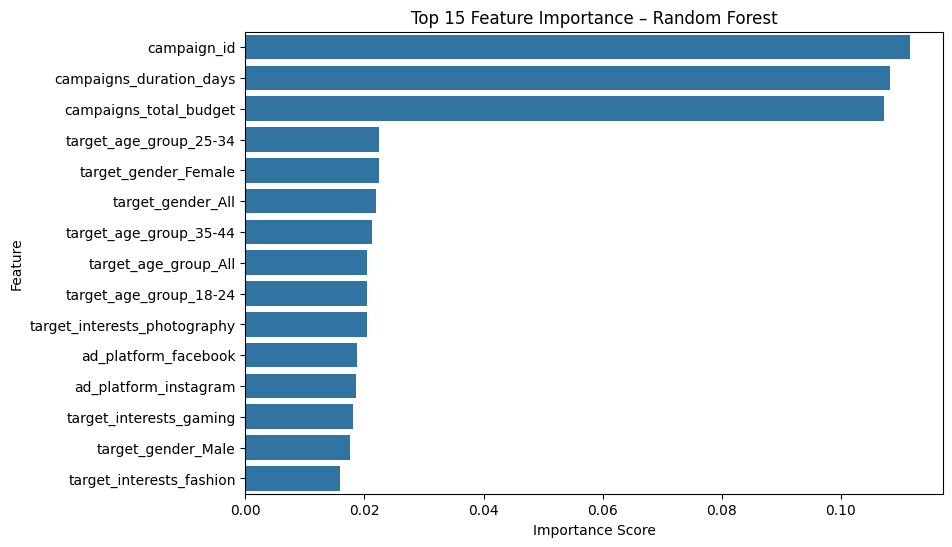

In [14]:
import pandas as pd
import numpy as np

ohe = rf_model.named_steps["preprocess"] \
    .named_transformers_["cat"] \
    .named_steps["onehot"]

cat_features = ohe.get_feature_names_out(cat_cols)
feature_names = list(num_cols) + list(cat_features)

importances = rf_model.named_steps["clf"].feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False).head(15)

plt.figure(figsize=(9,6))
sns.barplot(
    data=fi,
    x="importance",
    y="feature",
    orient="h"
)
plt.title("Top 15 Feature Importance – Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()




# **Nhận định kết quả từ Feature Importance**

- Chiến dịch là yếu tố quyết định mạnh nhất
campaign_id (0.1116), campaigns_duration_days (0.1083), campaigns_total_budget (0.1073)
→ Ba biến này chiếm ~32% tổng mức độ ảnh hưởng, cho thấy hiệu quả quảng cáo phụ thuộc chủ yếu vào cách thiết kế, thời gian và ngân sách campaign.

- Campaign chạy đủ lâu mang lại hiệu quả cao hơn
campaigns_duration_days (0.1083) đứng thứ 2 toàn bộ mô hình
→ Campaign quá ngắn thường kém hiệu quả do thuật toán và người dùng chưa đủ thời gian tương tác.

- Ngân sách quan trọng nhưng không quyết định tuyệt đối
campaigns_total_budget (0.1073) cao nhưng không vượt trội hơn campaign_id
→ Chi nhiều tiền không đảm bảo hiệu quả nếu campaign không được thiết kế tốt.

- Nhóm tuổi 25–34 phản hồi quảng cáo tốt nhất
target_age_group_25-34 (0.0225) cao nhất trong nhóm nhân khẩu học
→ Đây là nhóm khách hàng nên ưu tiên target.

- Giới tính không tạo khác biệt lớn
target_gender_Female (0.0224), Male (0.0176), All (0.0220)
→ Hiệu quả giữa các giới tính không chênh lệch đáng kể, không cần tách campaign theo giới.

- Sở thích chỉ mang tính tinh chỉnh
Photography (0.0205), Gaming (0.0181), Fashion (0.0160), Sports (0.0143)
→ Dùng để tối ưu thêm, nhưng không phải yếu tố quyết định chính.

- Facebook và Instagram có mức ảnh hưởng tương đương
ad_platform_facebook (0.0187), ad_platform_instagram (0.0187)
→ Không có nền tảng nào vượt trội rõ rệt → nên phân bổ ngân sách linh hoạt.

# **So sánh Accuracy giữa KNN và RF**

/tmp/ipython-input-1526899688.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


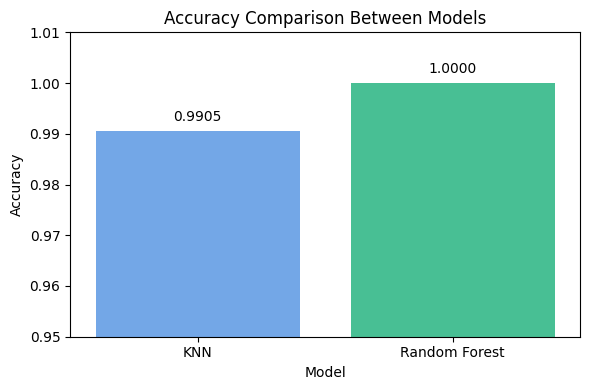

In [19]:
import pandas as pd

# Accuracy đã có từ kết quả trước đó
model_names = ["KNN", "Random Forest"]
accuracy_scores = [0.9905, 1.0]

# Tạo DataFrame
df_accuracy = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracy_scores
})

df_accuracy


plt.figure(figsize=(6,4))
sns.barplot(
    data=df_accuracy,
    x="Model",
    y="Accuracy",
    palette=["#60A5FA", "#34D399"]
)

plt.ylim(0.95, 1.01)
plt.title("Accuracy Comparison Between Models")
plt.ylabel("Accuracy")
plt.xlabel("Model")

# Ghi số lên cột
for index, value in enumerate(df_accuracy["Accuracy"]):
    plt.text(index, value + 0.002, f"{value:.4f}", ha="center")

plt.tight_layout()
plt.show()
